# ESPIRiT

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage.data import shepp_logan_phantom
import sigpy.mri

from espirit import espirit_calib

/Users/chinmay/miniconda3/envs/test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def init_phantom(resolution):
    image = shepp_logan_phantom().astype(np.float32)  # Shape format (H,W)
    image = resize(image, resolution, anti_aliasing=True)
    image = torch.tensor(image, dtype=torch.float)
    image = (image + 1j * torch.zeros_like(image))
    return image

def fft2c(image):
    image = torch.fft.ifftshift(image, dim=(-2, -1))
    kspace = torch.fft.fft2(image, dim=(-2, -1))
    kspace = torch.fft.fftshift(kspace, dim=(-2, -1))
    return kspace

def ifft2c(kspace):
    kspace = torch.fft.ifftshift(kspace, dim=(-2, -1))
    image = torch.fft.ifft2(kspace, dim=(-2, -1))
    image = torch.fft.fftshift(image, dim=(-2, -1))
    return image

def generate_sampling_mask(size, sample_fraction=0.5, sampling_scheme='variable-density', sampling_dim_option='1D'):

    num_rows, num_cols = size
    mask = np.zeros((num_rows, num_cols))
    
    if sampling_dim_option == '1D':

        if sampling_scheme == 'uniform':
            pmf = None
        
        elif sampling_scheme == 'variable-density':

            center_fraction = 0.25
            assert sample_fraction > center_fraction

            num_center_cols = int(center_fraction * num_cols)
            center_cols_range = (num_cols // 2 - num_center_cols // 2,  num_cols // 2 + num_center_cols // 2)
            mask[:, center_cols_range[0] : center_cols_range[1]] = 1
            
            pmf = np.ones(num_cols)
            pmf[center_cols_range[0] : center_cols_range[1]] = 0
            pmf = pmf / pmf.sum()
            
            sample_fraction = sample_fraction - center_fraction

        num_sample_lines = int(sample_fraction * num_cols)
        sampled_lines = np.random.choice(np.arange(num_cols), size=num_sample_lines, replace=False, p=pmf)        
        mask[:, sampled_lines] = 1

    elif sampling_dim_option == '2D':

        if sampling_scheme == 'uniform':
            pmf = None
        
        elif sampling_scheme == 'variable-density':
            # TODO
            pass
        
        grid_i, grid_j = np.meshgrid(np.arange(num_rows), np.arange(num_cols), indexing='ij')
        kspace_coords = np.stack((grid_i.flatten(), grid_j.flatten()), dim=1)
        num_samples = int(sample_fraction * (num_rows * num_cols))
        idxs = np.random.choice(np.arange(num_rows * num_cols), size=num_samples, replace=False, p=pmf)
        sampled_coords = kspace_coords[idxs]
        mask[sampled_coords[:, 0], sampled_coords[:, 1]] = 1

    return torch.tensor(mask.astype(bool))

def rss_combine(coil_images):
    return torch.sqrt(torch.sum(coil_images ** 2, dim=0))

def imshow(ndarray, ax=None, title=''):
    show = False
    if ax is None:
        show = True
        ax = plt.gca()
    ax.imshow(torch.squeeze(ndarray), cmap='gray')
    ax.set_axis_off()
    ax.set_title(title)
    if show: plt.show()

### Load data

In [3]:
# Settings

SIZE = 128
NUM_COILS = 8
ACCELERATION = 2

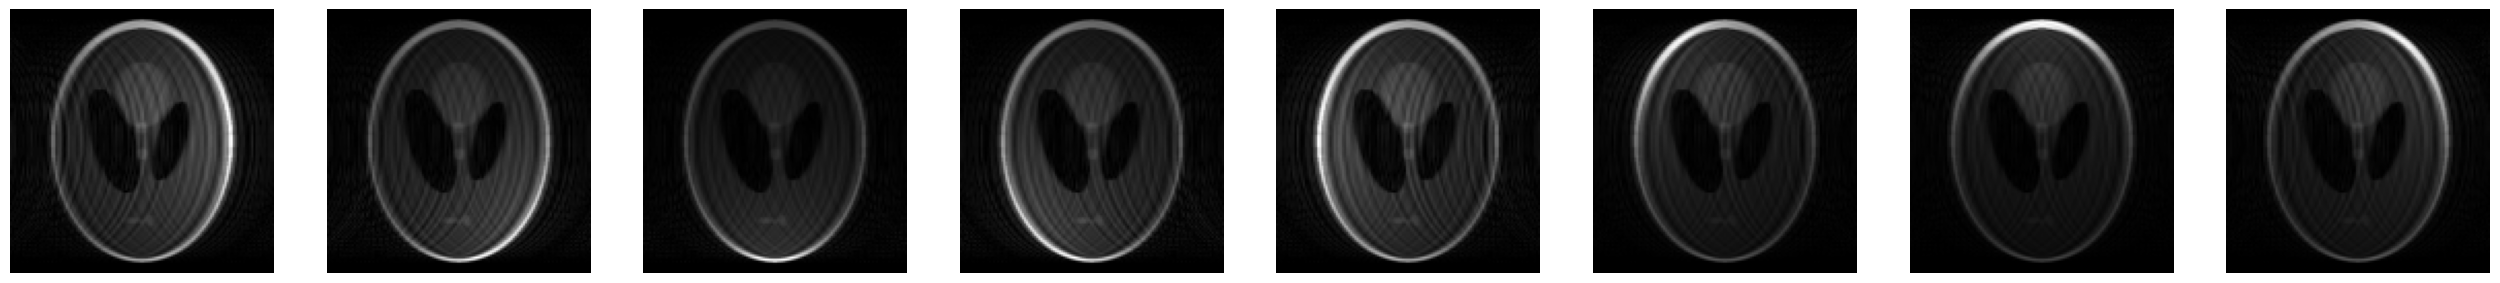

In [4]:
image_gt = init_phantom((SIZE, SIZE))   # Complex tensor, shape (H,W)

# Simulate CSMs
csm = torch.tensor(sigpy.mri.birdcage_maps((NUM_COILS, SIZE, SIZE), r=1.5, dtype=np.complex64))  # Shape format (C,H,W)
csm = csm / torch.norm(csm, p=2, dim=0, keepdim=True)

# Simulate multi-coil undersampled data
mask = generate_sampling_mask(tuple(image_gt.shape), 1 / ACCELERATION)
mask = mask.unsqueeze(0)
kspace = fft2c(image_gt * csm) * mask # Simulate undersmapling

coil_images = ifft2c(kspace)  # Shape format (C,H,W)
fig, axs = plt.subplots(1, NUM_COILS, figsize=(NUM_COILS*4, 4))
for c in range(NUM_COILS):
    imshow(torch.abs(coil_images[c, :, :]), ax=axs[c])
plt.show()

### Calibration

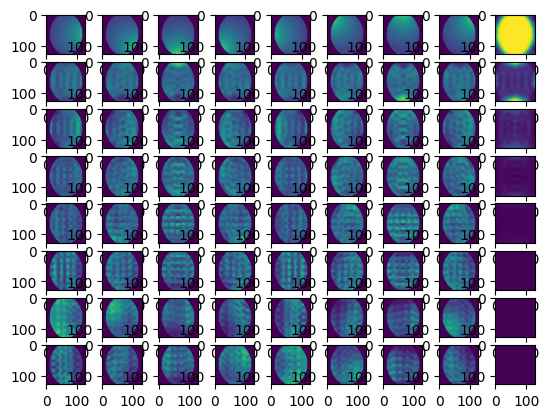

In [5]:

espirit_maps, eigenvalues = espirit_calib(kspace, calib_size=24, kernel_size=6, nullspace_cutoff=0.02, eigenvalue_thresh=0.95)

fig, axs = plt.subplots(NUM_COILS,NUM_COILS+1)
for comp in range(NUM_COILS):
    for chan in range(NUM_COILS):
        axs[comp][chan].imshow(espirit_maps[comp][chan].abs(), vmax=1)
    axs[comp][chan+1].imshow(eigenvalues[:,comp].reshape((SIZE,SIZE)).abs(), vmax=1)
plt.show()

EspiritCalib: 100%|██████████| 100/100 [00:00<00:00, 269.77it/s]


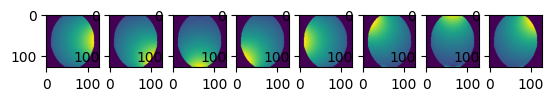

In [6]:
# Baseline
sigpy_esp_maps = sigpy.mri.app.EspiritCalib(kspace.numpy(), calib_width=24, thresh=0.02, kernel_width=6, crop=0.95).run()

fig, axs = plt.subplots(1,NUM_COILS)
for chan in range(NUM_COILS):
    axs[chan].imshow(np.abs(sigpy_esp_maps[chan]))
plt.show()

### Reconstruction

In [7]:
class SENSEOperator:
    def __init__(self, csm, mask):
        self.csm = csm
        self.mask = mask
    def __call__(self, image):
        return fft2c(self.csm * image) * self.mask
    def H(self, kspace):
        return torch.sum(self.csm.conj() * ifft2c(self.mask * kspace), dim=0)
    
def conjdot(a, b):
    return torch.abs(torch.sum(torch.conj(a) * b))

def cg_sense(kspace, csm, mask, eps=1e-6):
    
    # Linear operators
    E = SENSEOperator(csm, mask)

    # Init state
    a = E.H(kspace)  # (H, W)
    b = torch.zeros_like(a)  # (H, W)
    p = a.clone()          # (H, W)
    r = a.clone()          # (H, W)

    # Precompute
    rdotr_prev = conjdot(r, r)

    # Loop
    while True:

        delta = rdotr_prev / conjdot(a, a)
        if delta < eps:
            break
        
        q = E.H(E(p))
        b += (rdotr_prev / conjdot(p, q)) * p
        r -= (rdotr_prev / conjdot(p, q)) * q
        rdotr = conjdot(r, r)
        p = r + (rdotr / rdotr_prev) * p
        
        rdotr_prev = rdotr

    return b

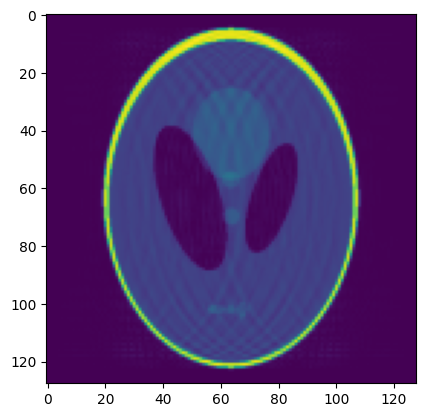

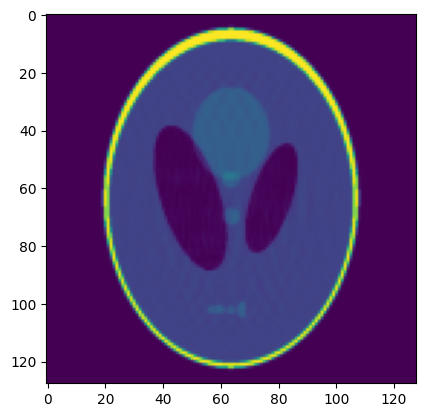

In [8]:
# SENSE recon with original CSMs
image_recon = cg_sense(kspace, csm, mask, eps=1e-10)
plt.imshow(image_recon.abs()); plt.show()

# SENSE recon with ESPIRiT CSMs
espirit_csm = espirit_maps[0]
image_recon = cg_sense(kspace, espirit_csm, mask, eps=1e-10)
plt.imshow(image_recon.abs()); plt.show()

